   YEAR  MONTH       SUPPLIER ITEM CODE  \
0  2026      8  20705 IMPORTS    180363   
1  2026      8  20705 IMPORTS    171162   
2  2026      8  20705 IMPORTS    180424   
3  2026      8  20705 IMPORTS    171163   
4  2026      8      AFARO LLC    348420   

                        ITEM DESCRIPTION ITEM TYPE RETAIL SALES  \
0         CAN' LEANDRO LES FINQUES 750ML      WINE         0.00   
1                    PROSECCO 84 - 750ML      WINE         0.00   
2       FENTO BICO DA RAN ALBARINO 750ML      WINE         0.00   
3  BENNATI CASTELLANO PINOT GRIGIO 750ML      WINE         0.00   
4    CH ROCHER CALON ST. EMILION - 750ML      WINE         3.41   

  RETAIL TRANSFERS WAREHOUSE SALES  
0             0.00            1.00  
1             0.00            7.00  
2             0.00            1.00  
3             0.00           10.00  
4             2.00            0.00  
(341037, 9)
<class 'pandas.DataFrame'>
RangeIndex: 341037 entries, 0 to 341036
Data columns (total 9 columns):
 #   

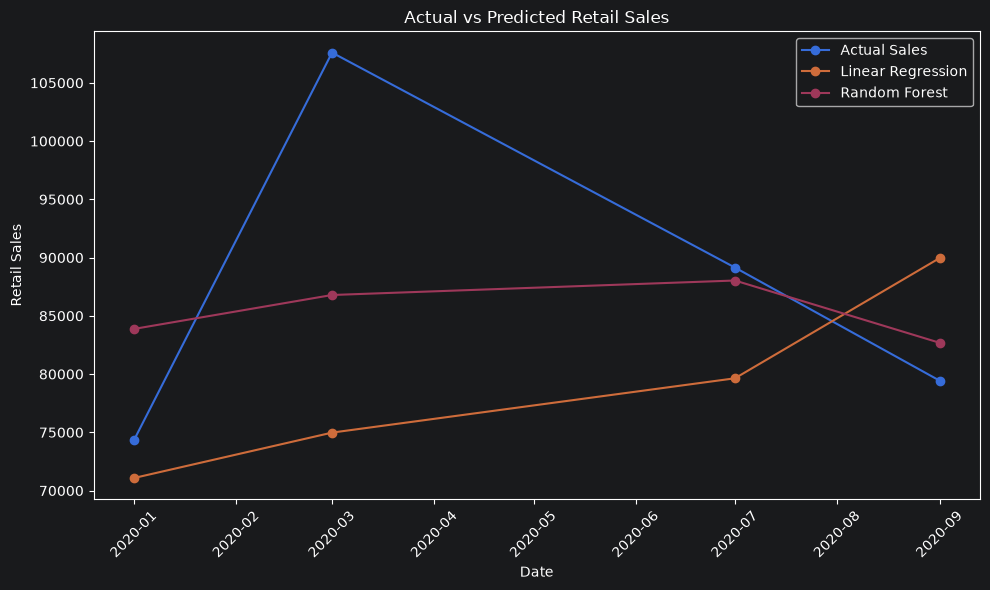


STEP 5: MODEL EVALUATION
               Model           MAE          RMSE  R2 Score
0  Linear Regression  13973.302027  17858.008925 -0.976954
1      Random Forest   8681.324150  11575.742708  0.169331

Best Model based on MAE:
Random Forest

Best Model based on RMSE:
Random Forest

Best Model based on R2 Score:
Random Forest

BEST PERFORMING MODEL
Random Forest

Evaluation results saved as:
model_evaluation_results.csv

STEP 6: BUSINESS INSIGHTS

1. Expected Future Sales Trend:
The forecasting models provide estimates of future retail sales based on historical sales patterns, lag features, rolling averages, and seasonal information.

2. Seasonal Patterns:
Average sales by month:
MONTH
12    128848.570000
11     98346.955000
3      96018.130000
5      92508.260000
6      90779.800000
7      88884.513333
8      87286.885000
10     86874.235000
9      82933.653333
4      79051.380000
2      78360.730000
1      75404.646667
Name: RETAIL_SALES, dtype: float64

Month with highest average s

In [2]:
import pandas as pd
# ==========================================
# STEP 2: Data Preparation
# ==========================================
df = pd.read_csv("Warehouse and Retail Sales.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
# Convert sales columns to numeric.
# Invalid/non-numeric values are converted to NaN.
sales_cols = [
    "RETAIL SALES",
    "RETAIL TRANSFERS",
    "WAREHOUSE SALES"
]

for col in sales_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    print(df.dtypes)
    print(df.isnull().sum())# checking missing values
# As SUPPLIER is a text field so we use .fillna("Unknown") to replace missing values with (NaN)
df["SUPPLIER"] = df["SUPPLIER"].fillna("Unknown")
df["ITEM TYPE"] = df["ITEM TYPE"].fillna("Unknown")

sales_cols = [
    "RETAIL SALES",
    "RETAIL TRANSFERS",
    "WAREHOUSE SALES"
]
for col in sales_cols:
    df[col] = df[col].fillna(0)
print(df.isnull().sum())
print(df.dtypes)
print("Duplicates:", df.duplicated().sum())
# Year aur Month check , Month ideally 1 se 12 ke beech hone chahiye.
print("Years:", df["YEAR"].unique())
print("Minimum Month:", df["MONTH"].min())
print("Maximum Month:", df["MONTH"].max())
# Negative sales check,Isse pata chalega sales columns mein koi negative value hai ya nahi.
sales_cols = [
    "RETAIL SALES",
    "RETAIL TRANSFERS",
    "WAREHOUSE SALES"
]

for col in sales_cols:
    print(col, "negative values:", (df[col] < 0).sum())

# transform that new DATE column from an object type into a proper datetime64[ns] data type.
df["DATE"] = pd.to_datetime(
    df["YEAR"].astype(str) + "-" + df["MONTH"].astype(str) + "-01"
)
print(df[["YEAR", "MONTH", "DATE"]].head())
# Sort data chronologically and reset the index.
# drop=True prevents the old index from becoming a new column.
df = df.sort_values("DATE").reset_index(drop=True)
print(df[["DATE", "YEAR", "MONTH"]].head())
# Detect Outliers
sales_cols = [
    "RETAIL SALES",
    "RETAIL TRANSFERS",
    "WAREHOUSE SALES"
]

for col in sales_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, "Outliers:", outliers)
# make monthly sales dataset
monthly_sales = df.groupby("DATE")["RETAIL SALES"].sum().reset_index()
monthly_sales.columns = ["DATE", "RETAIL_SALES"]
print(monthly_sales.head())
print(monthly_sales.tail())
# Check missing months
expected_dates = pd.date_range(
    start=monthly_sales["DATE"].min(),
    end=monthly_sales["DATE"].max(),
    freq="MS"
)

missing_dates = expected_dates.difference(monthly_sales["DATE"])

print("Missing months:")
print(missing_dates)
#  Separate 2026 data
historical_data = monthly_sales[
    monthly_sales["DATE"] < "2021-01-01"
].copy()

print("\nHistorical data:")
print(historical_data)

print("\nHistorical data shape:", historical_data.shape)


# ==========================================
# STEP 3: FEATURE ENGINEERING
# ==========================================

# Create a copy for feature engineering

forecast_data = historical_data.copy()

# Sort by date
forecast_data = (
    forecast_data
    .sort_values("DATE")
    .reset_index(drop=True)
)
# MONTH
forecast_data["MONTH"] = (
    forecast_data["DATE"].dt.month
)
# QUARTER
forecast_data["QUARTER"] = (
    forecast_data["DATE"].dt.quarter
)
# YEAR
forecast_data["YEAR"] = (
    forecast_data["DATE"].dt.year
)

#  DAY OF WEEK
# Since our data is monthly,
# we use the first day of each month.
forecast_data["DAY_OF_WEEK"] = (
    forecast_data["DATE"].dt.dayofweek
)
# 5. SEASONAL INDICATOR

# 1=Winter
# 2 = Spring
# 3 = Summer
# 4 = Autumn
forecast_data["SEASON"] = (
    forecast_data["MONTH"].map({
        12: 1,
        1: 1,
        2: 1,

        3: 2,
        4: 2,
        5: 2,

        6: 3,
        7: 3,
        8: 3,

        9: 4,
        10: 4,
        11: 4
    })
)
# PROMOTIONAL FACTOR
# The dataset does not contain promotion,
# discount, or campaign information.
# Therefore, we do NOT create fake
# promotional values.

# LAG FEATURES
# Previous month's sales
forecast_data["LAG_1"] = (
    forecast_data["RETAIL_SALES"].shift(1)
)

# Sales from 2 months ago
forecast_data["LAG_2"] = (
    forecast_data["RETAIL_SALES"].shift(2)
)
# Sales from 3 months ago
forecast_data["LAG_3"] = (
    forecast_data["RETAIL_SALES"].shift(3)
)

# 8. ROLLING AVERAGES
# Previous 3 months average
forecast_data["ROLLING_MEAN_3"] = (
    forecast_data["RETAIL_SALES"]
    .shift(1)
    .rolling(window=3)
    .mean()
)
# Previous 6 months average

forecast_data["ROLLING_MEAN_6"] = (
    forecast_data["RETAIL_SALES"]
    .shift(1)
    .rolling(window=6)
    .mean()
)
# DISPLAY FEATURE ENGINEERED DATA
print("\nFeature Engineered Data:")
print(
    forecast_data.head(10)
)

print("\nFeature Engineered Columns:")
print(
    forecast_data.columns
)

# CHECK MISSING VALUES CREATED
print("\nMissing Values After Feature Engineering:")
print(
    forecast_data.isnull().sum()
)
# REMOVE INITIAL NaN ROWS
# Lag and rolling features create NaN values
# at the beginning because previous months
# are not available.
forecast_data = (
    forecast_data
    .dropna()
    .reset_index(drop=True)
)

print("\nData After Removing Initial NaN Rows:")
print(
    forecast_data.head()
)
print("\nFinal Forecasting Dataset Shape:")
print(
    forecast_data.shape
)
# CHRONOLOGICAL TRAIN / TEST SPLIT
# 80% training
# 20% testing
split_index = int(
    len(forecast_data) * 0.8
)
train = forecast_data.iloc[
    :split_index
].copy()

test = forecast_data.iloc[
    split_index:
].copy()

print("\nTraining Data Shape:")
print(train.shape)
print("\nTesting Data Shape:")
print(test.shape)
print("\nTraining Period:")
print(
    train["DATE"].min(),
    "to",
    train["DATE"].max()
)
print("\nTesting Period:")
print(
    test["DATE"].min(),
    "to",
    test["DATE"].max()
)
# CREATE X AND Y
# Target variable
y_train = train["RETAIL_SALES"]
y_test = test["RETAIL_SALES"]
# Features

feature_cols = [
    "MONTH",
    "QUARTER",
    "YEAR",
    "DAY_OF_WEEK",
    "SEASON",
    "LAG_1",
    "LAG_2",
    "LAG_3",
    "ROLLING_MEAN_3",
    "ROLLING_MEAN_6"
]
X_train = train[feature_cols].copy()
X_test = test[feature_cols].copy()
# DISPLAY FINAL MODEL-READY DATA
print("\nX_train:")
print(X_train)

print("\ny_train:")
print(y_train)

print("\nX_test:")
print(X_test)

print("\ny_test:")
print(y_test)
# SAVE FILES
# Save complete cleaned dataset
df.to_csv(
    "cleaned_warehouse_retail_sales.csv",
    index=False
)
# Save feature engineered forecasting dataset
forecast_data.to_csv(
    "feature_engineered_sales.csv",
    index=False
)
# Save training and testing datasets
train.to_csv(
    "train_data.csv",
    index=False
)
test.to_csv(
    "test_data.csv",
    index=False
)

print("\n==========================================")
print("PREPROCESSING AND FEATURE ENGINEERING COMPLETED")
print("==========================================")

print("\nFiles saved:")
print("1. cleaned_warehouse_retail_sales.csv")
print("2. feature_engineered_sales.csv")
print("3. train_data.csv")
print("4. test_data.csv")
# ==========================================
# STEP 4: MODEL DEVELOPMENT
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# ==========================================
# MODEL 1: LINEAR REGRESSION
# ==========================================

linear_model = LinearRegression()
# Train the model
linear_model.fit(X_train, y_train)
# Make predictions
linear_pred = linear_model.predict(X_test)
print("\nLinear Regression Predictions:")
print(linear_pred)


# ==========================================
# MODEL 2: RANDOM FOREST
# ==========================================
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
# Train the model
random_forest_model.fit(X_train, y_train)
# Make predictions
rf_pred = random_forest_model.predict(X_test)
print("\nRandom Forest Predictions:")
print(rf_pred)
# ==========================================
# MODEL EVALUATION
# ==========================================
# Linear Regression metrics
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)
linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)
linear_r2 = r2_score(
    y_test,
    linear_pred
)
# Random Forest metrics
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)
rf_r2 = r2_score(
    y_test,
    rf_pred
)

# ==========================================
# COMPARE MODELS
# ==========================================
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

print("\n==========================================")
print("MODEL COMPARISON")
print("==========================================")
print(model_comparison)

# ==========================================
# ACTUAL VS PREDICTED VALUES
# ==========================================
comparison = pd.DataFrame({
    "DATE": test["DATE"].values,
    "Actual Sales": y_test.values,
    "Linear Regression": linear_pred,
    "Random Forest": rf_pred
})
print("\nActual vs Predicted Sales:")
print(comparison)
# ==========================================
# SAVE MODEL PREDICTIONS
# ==========================================
comparison.to_csv(
    "model_predictions.csv",
    index=False
)
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)
print("\nModel results saved successfully.")
# VISUALIZE ACTUAL VS PREDICTED
plt.figure(figsize=(10, 6))
plt.plot(
    comparison["DATE"],
    comparison["Actual Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    comparison["DATE"],
    comparison["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    comparison["DATE"],
    comparison["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.title("Actual vs Predicted Retail Sales")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_retail_sales.png", dpi=300, bbox_inches="tight")
plt.show()
# ==========================================
# STEP 5: MODEL EVALUATION
# ==========================================
# 1. LINEAR REGRESSION EVALUATION
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)
# 2. RANDOM FOREST EVALUATION
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

# 3. MODEL COMPARISON TABLE
evaluation_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})
print("\n==========================================")
print("STEP 5: MODEL EVALUATION")
print("==========================================")
print(evaluation_results)
# 4. IDENTIFY BEST MODEL
# Lower MAE is better
best_mae_model = evaluation_results.loc[
    evaluation_results["MAE"].idxmin(),
    "Model"
]
# Lower RMSE is better
best_rmse_model = evaluation_results.loc[
    evaluation_results["RMSE"].idxmin(),
    "Model"
]

# Higher R2 is better
best_r2_model = evaluation_results.loc[
    evaluation_results["R2 Score"].idxmax(),
    "Model"
]
print("\nBest Model based on MAE:")
print(best_mae_model)

print("\nBest Model based on RMSE:")
print(best_rmse_model)

print("\nBest Model based on R2 Score:")
print(best_r2_model)
# 5. OVERALL BEST MODEL
# Give each metric equal importance.
# Rank: lower MAE/RMSE and higher R2 are better.

evaluation_results["MAE Rank"] = (
    evaluation_results["MAE"]
    .rank(ascending=True)
)

evaluation_results["RMSE Rank"] = (
    evaluation_results["RMSE"]
    .rank(ascending=True)
)

evaluation_results["R2 Rank"] = (
    evaluation_results["R2 Score"]
    .rank(ascending=False)
)

evaluation_results["Overall Rank"] = (
    evaluation_results["MAE Rank"]
    + evaluation_results["RMSE Rank"]
    + evaluation_results["R2 Rank"]
)
best_model = evaluation_results.loc[
    evaluation_results["Overall Rank"].idxmin(),
    "Model"
]
print("\n==========================================")
print("BEST PERFORMING MODEL")
print("==========================================")
print(best_model)
# 6. SAVE EVALUATION RESULTS
evaluation_results.to_csv(
    "model_evaluation_results.csv",
    index=False
)
print("\nEvaluation results saved as:")
print("model_evaluation_results.csv")

# ==========================================
# STEP 6: BUSINESS INSIGHTS
# ==========================================

print("\n==========================================")
print("STEP 6: BUSINESS INSIGHTS")
print("==========================================")
# 1. EXPECTED FUTURE SALES TREND
print("\n1. Expected Future Sales Trend:")
print(
    "The forecasting models provide estimates of future "
    "retail sales based on historical sales patterns, "
    "lag features, rolling averages, and seasonal information."
)
# 2. SEASONAL PATTERNS
print("\n2. Seasonal Patterns:")
seasonal_sales = (
    historical_data
    .assign(
        MONTH=historical_data["DATE"].dt.month
    )
    .groupby("MONTH")["RETAIL_SALES"]
    .mean()
    .sort_values(ascending=False)
)
print("Average sales by month:")
print(seasonal_sales)
highest_month = seasonal_sales.idxmax()
lowest_month = seasonal_sales.idxmin()
print(
    "\nMonth with highest average sales:",
    highest_month
)
print(
    "Month with lowest average sales:",
    lowest_month
)
# 3. IMPORTANT FACTORS AFFECTING SALES
print("\n3. Important Factors Affecting Sales:")
print(
    "Lagged sales and rolling averages are important "
    "forecasting features because recent sales activity "
    "can influence future sales."
)
print(
    "Seasonal indicators such as month and season "
    "help capture recurring changes in sales patterns."
)
# 4. INVENTORY REQUIREMENTS
print("\n4. Potential Inventory Requirements:")
print(
    "Higher forecasted sales periods may require higher "
    "inventory levels to avoid stockouts."
)
print(
    "Lower forecasted sales periods can be used to reduce "
    "excess inventory and storage costs."
)
# 5. MARKETING OPPORTUNITIES
print("\n5. Marketing and Promotional Opportunities:")
print(
    "Marketing campaigns can be planned before periods "
    "with historically higher sales."
)

print(
    "Promotional activities and discounts can be considered "
    "during lower-sales periods to increase customer demand."
)
# 6. BUSINESS DECISION IMPROVEMENTS
print("\n6. Business Decision Improvements:")
print(
    "Sales forecasts can support inventory planning, "
    "procurement, marketing, and resource allocation."
)
print(
    "The business should continuously update the forecasting "
    "model as new sales data becomes available."
)
# 7. HISTORICAL SALES SUMMARY
print("\n7. Historical Sales Summary:")
highest_sales_row = historical_data.loc[
    historical_data["RETAIL_SALES"].idxmax()
]
lowest_sales_row = historical_data.loc[
    historical_data["RETAIL_SALES"].idxmin()
]
print(
    "Highest historical monthly sales:",
    highest_sales_row["DATE"],
    "=",
    highest_sales_row["RETAIL_SALES"]
)
print(
    "Lowest historical monthly sales:",
    lowest_sales_row["DATE"],
    "=",
    lowest_sales_row["RETAIL_SALES"]
)
# 8. FINAL BUSINESS RECOMMENDATIONS
print("\n==========================================")
print("FINAL BUSINESS RECOMMENDATIONS")
print("==========================================")

print("1. Maintain higher inventory before high-demand periods.")
print("2. Reduce excess inventory during lower-demand periods.")
print("3. Use historical seasonal patterns for marketing planning.")
print("4. Monitor recent sales trends using lag and rolling features.")
print("5. Update forecasts regularly when new sales data becomes available.")
print("6. Use forecasting results to improve procurement and inventory decisions.")